In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/heart-disease-dataset/heart.csv


# 🫀 Heart Disease Prediction Project

## 🎯 Goal
The goal of this project is to **predict whether a patient has heart disease** based on clinical and demographic features using machine learning models.  

We analyzed the dataset, performed **exploratory data analysis (EDA)**, handled duplicates/outliers, built multiple models, and selected the **best-performing model (Logistic Regression)** for deployment.  

---

## 📊 Dataset Overview
The dataset contains **1025 records** and **14 columns**. All features are numeric, and the target variable is binary (`0` = no heart disease, `1` = heart disease).  

### Columns Description and Mapping

| Column       | Description                                           | Possible Values / Mapping |
|-------------|-------------------------------------------------------|---------------------------|
| **age**     | Age of the patient in years                            | Numeric (29 – 77)         |
| **sex**     | Gender of the patient                                  | 0 = Female, 1 = Male      |
| **cp**      | Chest pain type                                       | 0 = Typical angina <br> 1 = Atypical angina <br> 2 = Non-anginal pain <br> 3 = Asymptomatic |
| **trestbps**| Resting blood pressure (mm Hg)                        | Numeric                   |
| **chol**    | Serum cholesterol (mg/dl)                              | Numeric                   |
| **fbs**     | Fasting blood sugar > 120 mg/dl                        | 0 = False, 1 = True       |
| **restecg** | Resting electrocardiographic results                   | 0 = Normal <br> 1 = ST-T wave abnormality <br> 2 = Left ventricular hypertrophy |
| **thalach** | Maximum heart rate achieved                             | Numeric                   |
| **exang**   | Exercise-induced angina                                | 0 = No, 1 = Yes           |
| **oldpeak** | ST depression induced by exercise relative to rest     | Numeric                   |
| **slope**   | Slope of the peak exercise ST segment                  | 0 = Upsloping <br> 1 = Flat <br> 2 = Downsloping |
| **ca**      | Number of major vessels colored by fluoroscopy         | 0 – 4 numeric             |
| **thal**    | Thalassemia type                                       | 0 = Unknown <br> 1 = Fixed defect <br> 2 = Normal <br> 3 = Reversible defect |
| **target**  | Heart disease presence                                  | 0 = No heart disease <br> 1 = Heart disease |

---

✅ **Notes:**
- All features are numeric, making them suitable for models like Logistic Regression, Random Forest, and XGBoost.  
- Some categorical features (e.g., `cp`, `restecg`, `slope`, `thal`) are encoded as integers.  
- Target variable `target` is binary, which makes this a **binary classification problem**.


In [2]:

df = pd.read_csv("/kaggle/input/heart-disease-dataset/heart.csv")


print(df.head(5))

print(df.info())



   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 

In [3]:
print(df.shape)

print("Missing value checking")
print(df.isnull().sum())

(1025, 14)
Missing value checking
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [4]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [5]:
n_dup = df.duplicated().sum()
print(f"Duplicate rows: {n_dup}")


Duplicate rows: 723


In [6]:
df_orig = df.copy()
df = df.drop_duplicates().reset_index(drop=True)

# Check new shape
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (302, 14)


In [7]:

print("\nSummary Statistics (Numerical):")
print(df.describe())






Summary Statistics (Numerical):
             age         sex          cp    trestbps        chol         fbs  \
count  302.00000  302.000000  302.000000  302.000000  302.000000  302.000000   
mean    54.42053    0.682119    0.963576  131.602649  246.500000    0.149007   
std      9.04797    0.466426    1.032044   17.563394   51.753489    0.356686   
min     29.00000    0.000000    0.000000   94.000000  126.000000    0.000000   
25%     48.00000    0.000000    0.000000  120.000000  211.000000    0.000000   
50%     55.50000    1.000000    1.000000  130.000000  240.500000    0.000000   
75%     61.00000    1.000000    2.000000  140.000000  274.750000    0.000000   
max     77.00000    1.000000    3.000000  200.000000  564.000000    1.000000   

          restecg     thalach       exang     oldpeak       slope          ca  \
count  302.000000  302.000000  302.000000  302.000000  302.000000  302.000000   
mean     0.526490  149.569536    0.327815    1.043046    1.397351    0.718543   
std

# EDA

**Target Variable Distribution**

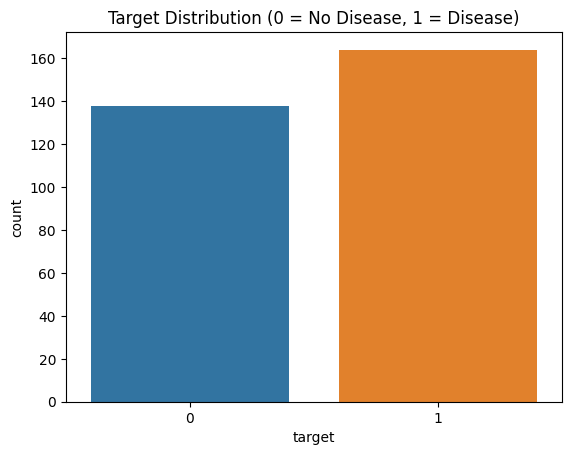

target
1    0.543046
0    0.456954
Name: proportion, dtype: float64


In [8]:
%matplotlib inline
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='target', data=df)
plt.title("Target Distribution (0 = No Disease, 1 = Disease)")
plt.show()

print(df['target'].value_counts(normalize=True))


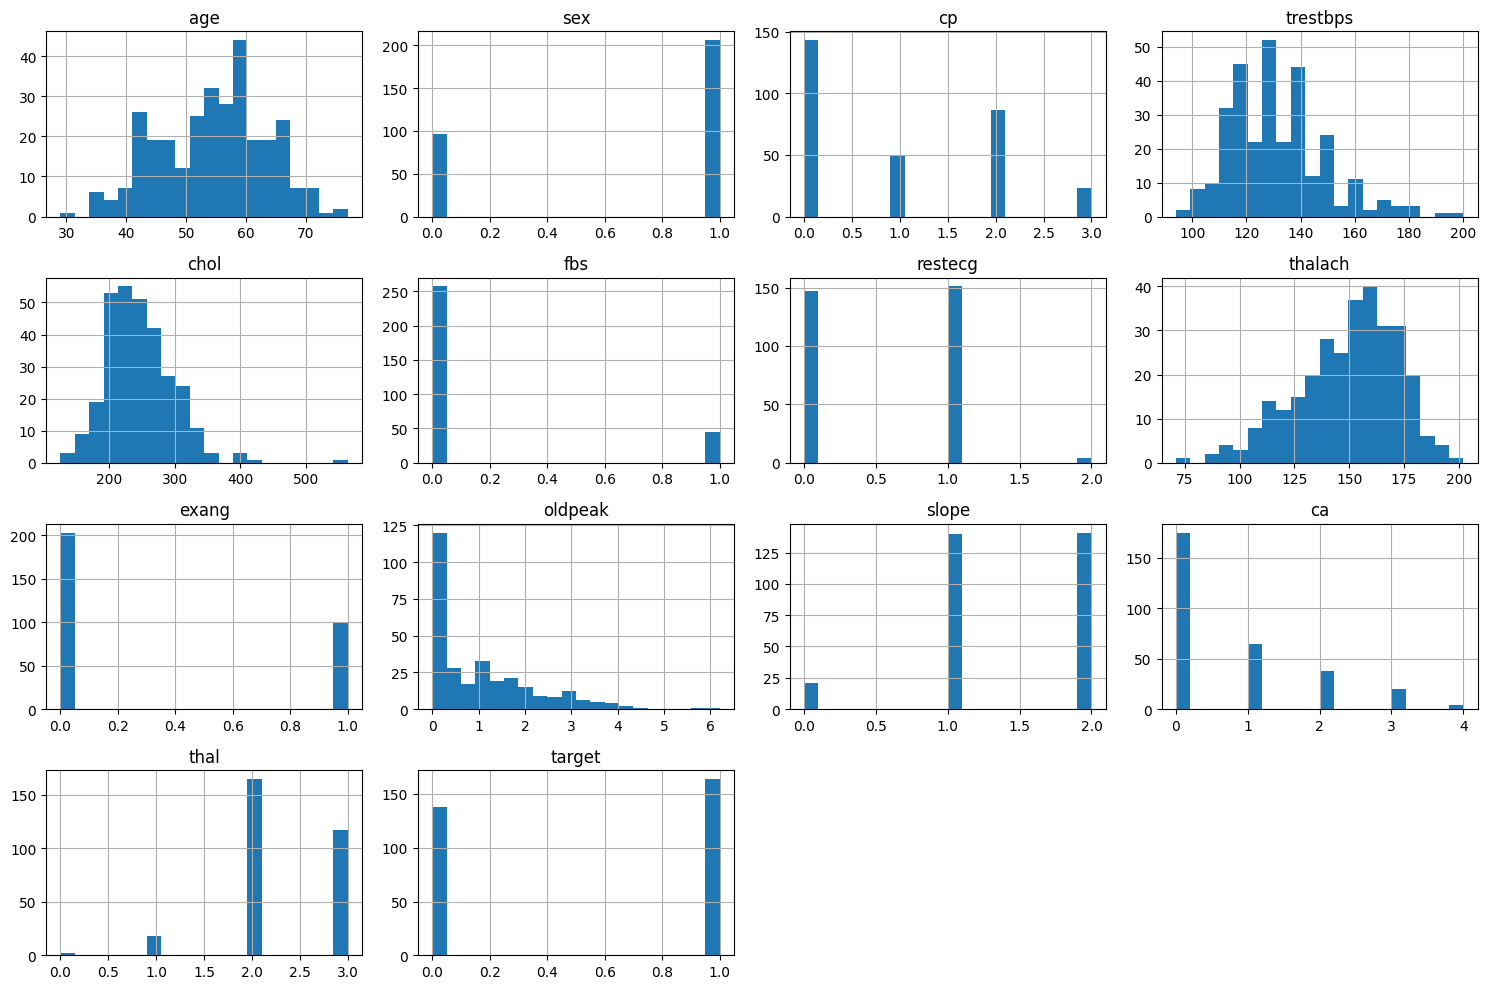

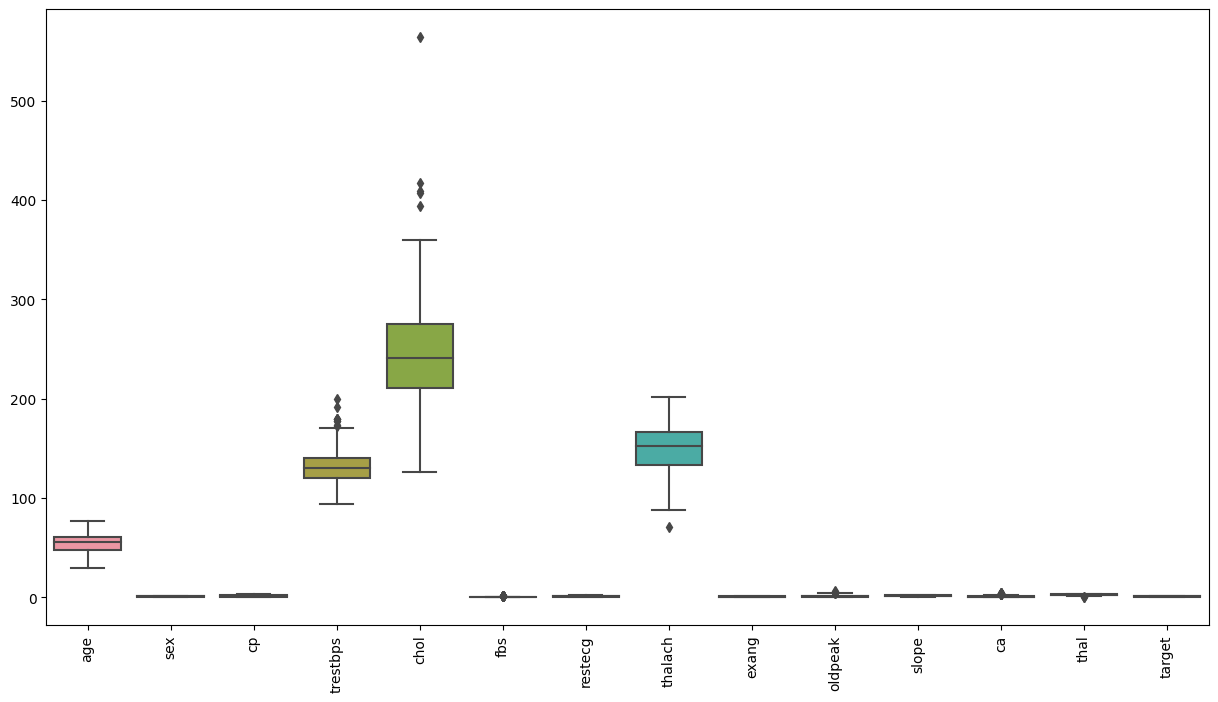

In [9]:
df.hist(figsize=(15,10), bins=20)
plt.tight_layout()
plt.show()

# Boxplots for outlier detection
plt.figure(figsize=(15,8))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()


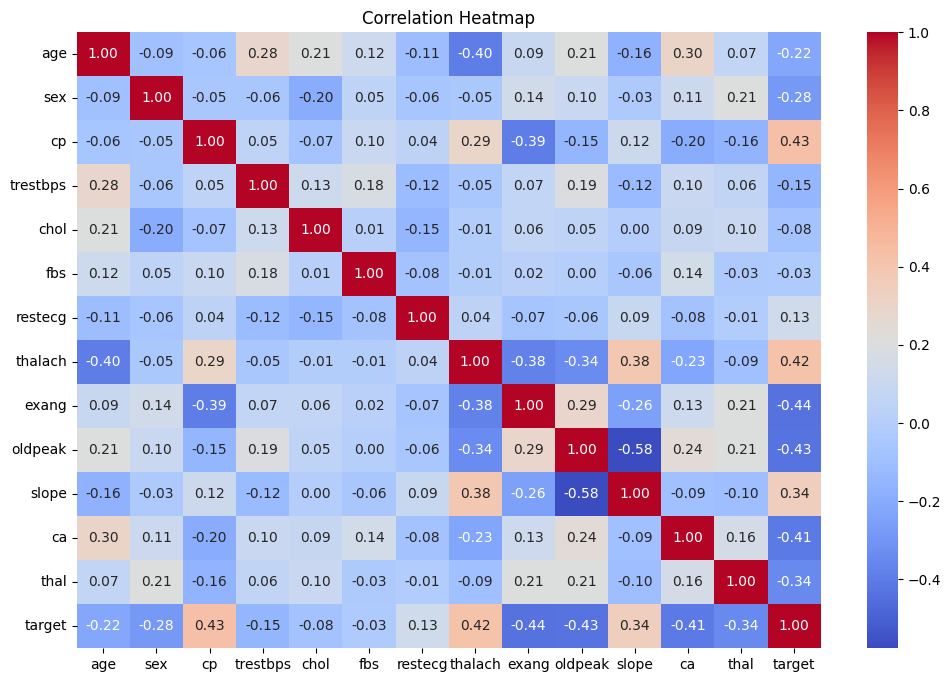

In [10]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


**Bivariate Analysis (Feature vs Target)**

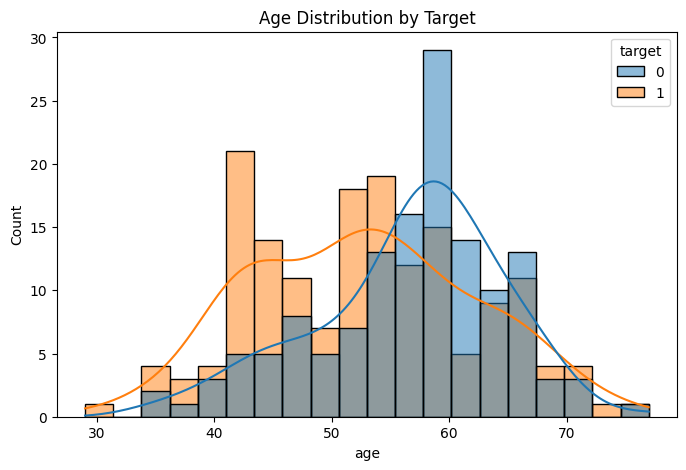

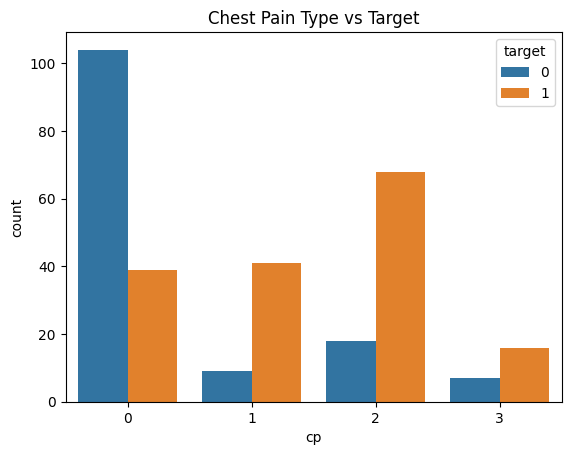

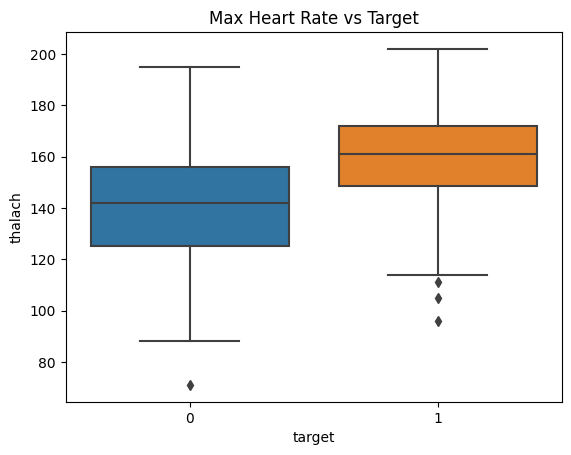

In [11]:
import warnings
warnings.filterwarnings("ignore")
# Example: Age distribution by target
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="age", hue="target", bins=20, kde=True)
plt.title("Age Distribution by Target")
plt.show()

# Chest Pain Type vs Target
sns.countplot(x="cp", hue="target", data=df)
plt.title("Chest Pain Type vs Target")
plt.show()

# Max Heart Rate vs Target
sns.boxplot(x="target", y="thalach", data=df)
plt.title("Max Heart Rate vs Target")
plt.show()


In [12]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

outliers = ((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).sum()
print("Outliers in each column:\n", outliers)


Outliers in each column:
 age          0
sex          0
cp           0
trestbps     9
chol         5
fbs         45
restecg      0
thalach      1
exang        0
oldpeak      5
slope        0
ca          24
thal         2
target       0
dtype: int64


In [13]:
df.shape

(302, 14)

 # Separate Features and Target

In [14]:

X = df.drop('target', axis=1)
y = df['target']

print("Feature shape:", X.shape)
print("Target shape:", y.shape)


Feature shape: (302, 13)
Target shape: (302,)


# Train-Test Split

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (241, 13)
Test shape: (61, 13)


# Preprocessing

In [16]:
from sklearn.preprocessing import StandardScaler

# Identify numeric columns (all are numeric, but some are categorical codes)
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
numeric_cols = [col for col in X.columns if col not in categorical_cols]

# Scaling numeric features
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])


# Different Model Training

In [17]:
# Step 1: Import required libraries
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

# Step 2: Prepare models
models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    "SVC": SVC(probability=True, random_state=42)
}

# Step 3: Train, evaluate, and cross-validate
cv_results = {}

for name, model in models.items():
    print(f"--- {name} ---")
    
    # Scaling only for Logistic Regression
    if name == "Logistic Regression":
        X_model_train = X_train_scaled
        X_model_test = X_test_scaled
    else:
        X_model_train = X_train
        X_model_test = X_test
    
    # Fit model
    model.fit(X_model_train, y_train)
    
    # Predictions
    y_pred = model.predict(X_model_test)
    y_prob = model.predict_proba(X_model_test)[:,1]
    
    # Accuracy & ROC-AUC
    acc = accuracy_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)
    
    # 5-fold Cross-Validation Accuracy
    if name == "Logistic Regression":
        cv_acc = cross_val_score(model, X_model_train, y_train, cv=5, scoring='accuracy')
    else:
        cv_acc = cross_val_score(model, X_model_train, y_train, cv=5, scoring='accuracy')
    
    cv_results[name] = {
        "Test Accuracy": acc,
        "Test ROC-AUC": roc,
        "CV Accuracy Mean": cv_acc.mean(),
        "CV Accuracy Std": cv_acc.std()
    }
    
    print(f"Test Accuracy: {acc:.4f}, Test ROC-AUC: {roc:.4f}")
    print(f"5-Fold CV Accuracy: Mean={cv_acc.mean():.4f}, Std={cv_acc.std():.4f}")
    print("\n")

# Step 4: Summary Table
import pandas as pd
cv_results_df = pd.DataFrame(cv_results).T.sort_values(by="Test Accuracy", ascending=False)
print("Summary of all models with CV:\n", cv_results_df)


--- Logistic Regression ---
Test Accuracy: 0.8033, Test ROC-AUC: 0.8701
5-Fold CV Accuracy: Mean=0.8216, Std=0.0210


--- Random Forest ---
Test Accuracy: 0.7541, Test ROC-AUC: 0.8615
5-Fold CV Accuracy: Mean=0.8132, Std=0.0300


--- XGBoost ---
Test Accuracy: 0.7213, Test ROC-AUC: 0.8323
5-Fold CV Accuracy: Mean=0.8048, Std=0.0258


--- SVC ---
Test Accuracy: 0.6066, Test ROC-AUC: 0.6970
5-Fold CV Accuracy: Mean=0.6644, Std=0.0696


Summary of all models with CV:
                      Test Accuracy  Test ROC-AUC  CV Accuracy Mean  \
Logistic Regression       0.803279      0.870130          0.821599   
Random Forest             0.754098      0.861472          0.813180   
XGBoost                   0.721311      0.832251          0.804847   
SVC                       0.606557      0.696970          0.664371   

                     CV Accuracy Std  
Logistic Regression         0.020999  
Random Forest               0.029971  
XGBoost                     0.025817  
SVC                    

<div style="padding: 10px; border-left: 5px solid #4CAF50; background-color: #f0fff0; color: #333; border-radius: 5px;">
<b>✅ Best Model Selected:</b> <br>
After comparing Logistic Regression, Random Forest, XGBoost, and SVC using Test Accuracy, ROC-AUC, and 5-Fold Cross-Validation, <b>Logistic Regression</b> was selected as the best model for heart disease prediction.  

Key observations:
- <b>Test Accuracy:</b> 80.33%  
- <b>Test ROC-AUC:</b> 0.8701  
- <b>CV Accuracy Mean:</b> 82.16%, <b>Std:</b> 0.021 → consistent and stable performance  
- Balanced performance for both positive and negative classes with minimal misclassification  

Hence, Logistic Regression provides the most reliable and interpretable results for deployment.
</div>


# Model Choosing

In [18]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# Hyperparameter grid
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']  # Supports both l1 and l2
}

lr = LogisticRegression(max_iter=1000, random_state=42)
lr_cv = GridSearchCV(lr, param_grid, cv=5, scoring='accuracy')
lr_cv.fit(X_train_scaled, y_train)

print("Best Hyperparameters:", lr_cv.best_params_)
print("Best CV Accuracy:", lr_cv.best_score_)


Best Hyperparameters: {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}
Best CV Accuracy: 0.8175170068027212


In [19]:
best_lr = lr_cv.best_estimator_

# Predict and evaluate
y_pred = best_lr.predict(X_test_scaled)
y_prob = best_lr.predict_proba(X_test_scaled)[:,1]

from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Test ROC-AUC:", roc_auc_score(y_test, y_prob))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))



Test Accuracy: 0.8032786885245902
Test ROC-AUC: 0.8701298701298702
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.75      0.78        28
           1       0.80      0.85      0.82        33

    accuracy                           0.80        61
   macro avg       0.80      0.80      0.80        61
weighted avg       0.80      0.80      0.80        61

Confusion Matrix:
 [[21  7]
 [ 5 28]]


# Feature Importance Analysis

     Feature  Coefficient
1        sex    -1.586379
2         cp     0.957633
8      exang    -0.832498
7    thalach     0.725452
11        ca    -0.685874
10     slope     0.586405
12      thal    -0.562972
9    oldpeak    -0.369614
6    restecg     0.348462
3   trestbps    -0.312337
4       chol    -0.223427
0        age     0.026689
5        fbs     0.000000


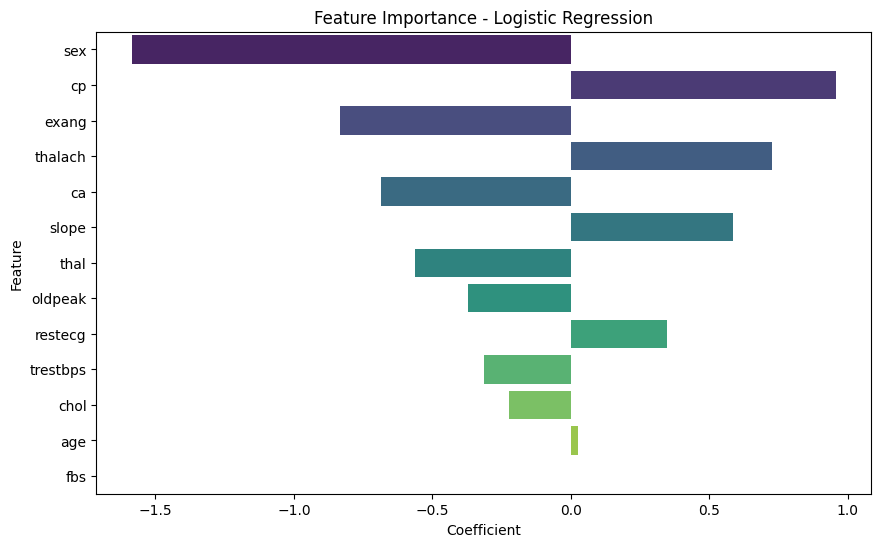

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Feature importance (coefficients)
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': best_lr.coef_[0]
}).sort_values(by='Coefficient', key=abs, ascending=False)

print(feature_importance)

# Plotting
plt.figure(figsize=(10,6))
sns.barplot(x='Coefficient', y='Feature', data=feature_importance, palette='viridis')
plt.title('Feature Importance - Logistic Regression')
plt.show()


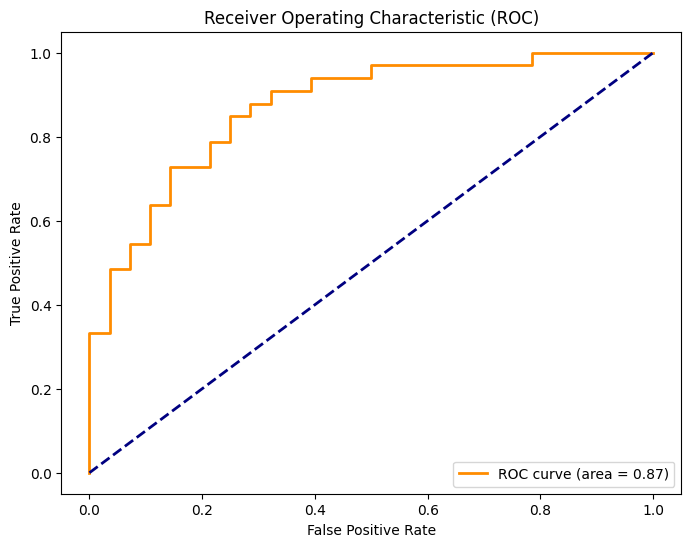

In [21]:
from sklearn.metrics import roc_curve, auc

y_prob = best_lr.predict_proba(X_test_scaled)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='lower right')
plt.show()


# Model Saving

In [22]:
import joblib

# Save the trained Logistic Regression model
joblib.dump(best_lr, 'logistic_heart_model.pkl')

# Save the StandardScaler used for preprocessing
joblib.dump(scaler, 'scaler.pkl')

print("Model and scaler saved successfully as .pkl files!")


Model and scaler saved successfully as .pkl files!
